# 🌍 Global Air Pollution — Clustering Analysis (final)

**ML Module Project | Unsupervised Learning**

### Objective
Discover meaningful groups of cities from pollutant-specific AQI profiles and evaluate those groups with multiple clustering metrics.


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import pycountry_convert as pc
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
print("✅ All libraries imported successfully")


## 2. Load & Inspect Dataset

In [ ]:
from pathlib import Path

candidate_files = [
    "global_air_pollution_dataset.csv",
    "global air pollution dataset.csv"
]
DATA_PATH = next((p for p in candidate_files if Path(p).exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Put the CSV beside the notebook and use either "
        "'global_air_pollution_dataset.csv' or 'global air pollution dataset.csv'."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset:", DATA_PATH)
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.head(8))


Dataset: global air pollution dataset.csv
Shape: (23463, 12)

Missing values:
Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

Duplicate rows: 0


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
5,United States of America,Punta Gorda,54,Moderate,1,Good,14,Good,11,Good,54,Moderate
6,Germany,Puttlingen,62,Moderate,1,Good,35,Good,3,Good,62,Moderate
7,Belgium,Puurs,64,Moderate,1,Good,29,Good,7,Good,64,Moderate


In [ ]:
print("Statistical Summary:")
df.describe().round(2)


Statistical Summary:


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.00,23463.00,23463.00,23463.00,23463.00
mean,72.01,1.37,35.19,3.06,68.52
std,56.06,1.83,28.10,5.25,54.80
min,6.00,0.00,0.00,0.00,0.00
25%,39.00,1.00,21.00,0.00,35.00
50%,55.00,1.00,31.00,1.00,54.00
75%,79.00,1.00,40.00,4.00,79.00
max,500.00,133.00,235.00,91.00,500.00


## 3. Data Preprocessing

### 3.1 Clean Missing Values & Add Continent Column

In [ ]:
df = df.dropna(subset=['City']).copy()
df['Country'] = df['Country'].fillna('Unknown')

manual_fixes = {
    'Iran (Islamic Republic of)': 'Asia',
    'Bolivia (Plurinational State of)': 'South America',
    'Venezuela (Bolivarian Republic of)': 'South America',
    'Republic of Korea': 'Asia',
    'Korea, South': 'Asia',
    'State of Palestine': 'Asia',
    'Unknown': 'Unknown'
}

def get_continent(country_name):
    if country_name in manual_fixes:
        return manual_fixes[country_name]
    try:
        code = pc.country_name_to_country_alpha2(country_name, cn_name_format='default')
        cont = pc.country_alpha2_to_continent_code(code)
        return {'AF':'Africa','AS':'Asia','EU':'Europe','NA':'North America',
                'SA':'South America','OC':'Oceania','AN':'Antarctica'}.get(cont,'Unknown')
    except:
        return 'Unknown'

df['Continent'] = df['Country'].apply(get_continent)

print(f"Rows after cleaning: {len(df)}")
print()
print("Continent distribution:")
print(df['Continent'].value_counts().to_string())


Rows after cleaning: 23462

Continent distribution:
Continent
Europe           8116
Asia             6566
North America    4060
South America    2337
Africa           1831
Unknown           427
Oceania           125


## 4. Feature Audit — Choosing Variables for Clustering

The clustering objective is to discover **pollutant profiles**, so the model should use pollutant-specific AQI variables.

`AQI Value` is an overall summary measure and is therefore kept for **post-clustering interpretation/validation**, not as an input feature.

`CO AQI Value` is audited below. If it has very little variation for most cities and extreme skew, it is excluded because it can add disproportionate influence without representing a broad pattern.


In [ ]:
audit_features = [
    "AQI Value", "CO AQI Value", "Ozone AQI Value",
    "NO2 AQI Value", "PM2.5 AQI Value"
]

audit = pd.DataFrame({
    "Mean": df[audit_features].mean(),
    "Median": df[audit_features].median(),
    "Std": df[audit_features].std(),
    "Skewness": df[audit_features].skew(),
    "P99": df[audit_features].quantile(0.99),
    "Max": df[audit_features].max()
}).round(2)

display(audit)

co = df["CO AQI Value"]
print(f"CO median: {co.median():.1f}")
print(f"CO mean:   {co.mean():.2f}")
print(f"CO skew:   {co.skew():.2f}")
print(f"CO > 50:   {(co > 50).sum():,} cities ({(co > 50).mean()*100:.2f}%)")


,Mean,Median,Std,Skewness,P99,Max
AQI Value,72.01,55.0,56.06,3.29,260.78,500
CO AQI Value,1.37,1.0,1.83,23.08,7.00,133
Ozone AQI Value,35.19,31.0,28.10,3.10,168.00,235
NO2 AQI Value,3.06,1.0,5.25,3.79,26.00,91
PM2.5 AQI Value,68.52,54.0,54.80,2.82,255.39,500


CO median: 1.0
CO mean:   1.37
CO skew:   23.08
CO > 50:   3 cities (0.01%)


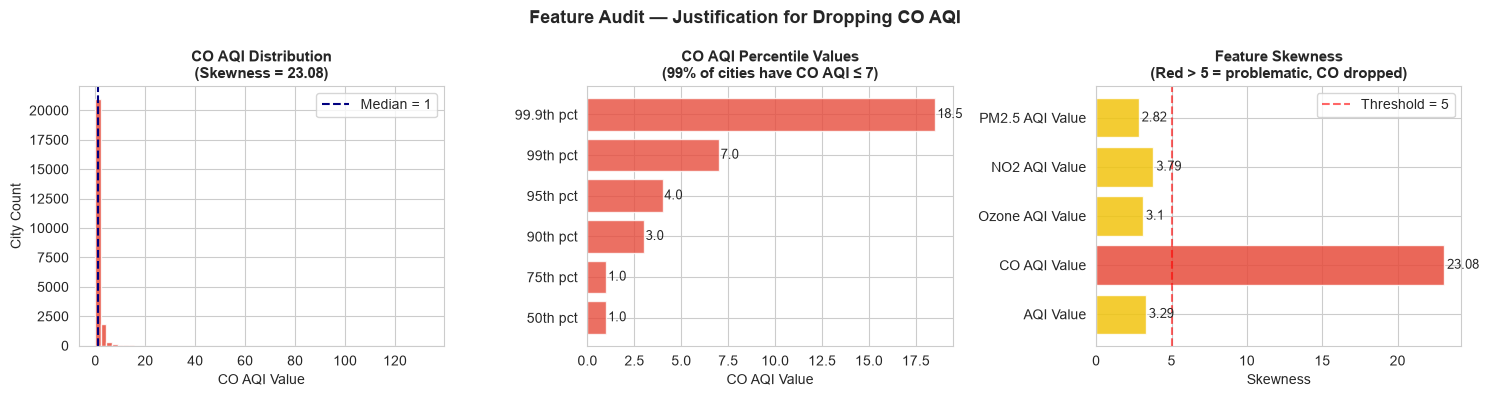

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['CO AQI Value'], bins=60, color='#e74c3c', alpha=0.85, edgecolor='white')
axes[0].set_title('CO AQI Distribution\n(Skewness = 23.08)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('CO AQI Value'); axes[0].set_ylabel('City Count')
axes[0].axvline(df['CO AQI Value'].median(), color='navy', linestyle='--',
                label=f'Median = {df["CO AQI Value"].median():.0f}')
axes[0].legend()

pcts = [50, 75, 90, 95, 99, 99.9]
vals = [df['CO AQI Value'].quantile(p/100) for p in pcts]
axes[1].barh([f'{p}th pct' for p in pcts], vals, color='#e74c3c', alpha=0.8)
axes[1].set_title('CO AQI Percentile Values\n(99% of cities have CO AQI ≤ 7)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('CO AQI Value')
for i, v in enumerate(vals):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

skews = df[audit_features].skew().round(2)
colors_skew = ['#e74c3c' if v > 5 else '#f1c40f' if v > 1 else '#2ecc71' for v in skews]
axes[2].barh(skews.index, skews.values, color=colors_skew, alpha=0.85)
axes[2].set_title('Feature Skewness\n(Red > 5 = problematic, CO dropped)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Skewness')
axes[2].axvline(5, color='red', linestyle='--', alpha=0.6, label='Threshold = 5')
axes[2].legend()
for i, v in enumerate(skews.values):
    axes[2].text(v + 0.2, i, f'{v}', va='center', fontsize=9)

plt.suptitle('Feature Audit — Justification for Dropping CO AQI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/A_co_feature_audit.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.1 CO AQI — Distributional Audit and Sensitivity Check

CO AQI is excluded from the final clustering feature set because its distribution is extremely
right-skewed (skewness ≈ 23.1): 99% of cities have CO AQI ≤ 7, while a small number of
outliers extend much higher.

As a sensitivity check, we compare K=4 clustering with and without CO using the same
StandardScaler and K-Means settings. The comparison is informative rather than a
single-metric decision: adding CO slightly increases Silhouette, but worsens Davies-Bouldin
and Calinski-Harabasz substantially. More importantly, the extreme skew means CO can give
disproportionate influence to a small number of cities.

Therefore, CO is excluded based primarily on its distributional behaviour and the goal of
capturing broad pollutant-composition patterns.


In [ ]:
# Final clustering feature representation
# Overall AQI is kept for interpretation/validation, not used as a clustering input.
# CO AQI is audited earlier and excluded because of its highly skewed,
# low-variation distribution.

features = [
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("Final clustering features:")
for feature in features:
    print(f"  • {feature}")

print(f"Feature matrix shape: {X_scaled.shape}")

Final clustering features:
  • Ozone AQI Value
  • NO2 AQI Value
  • PM2.5 AQI Value
Feature matrix shape: (23462, 3)


## 5. Exploratory Data Analysis

### 5.1 AQI Distribution & Category Breakdown

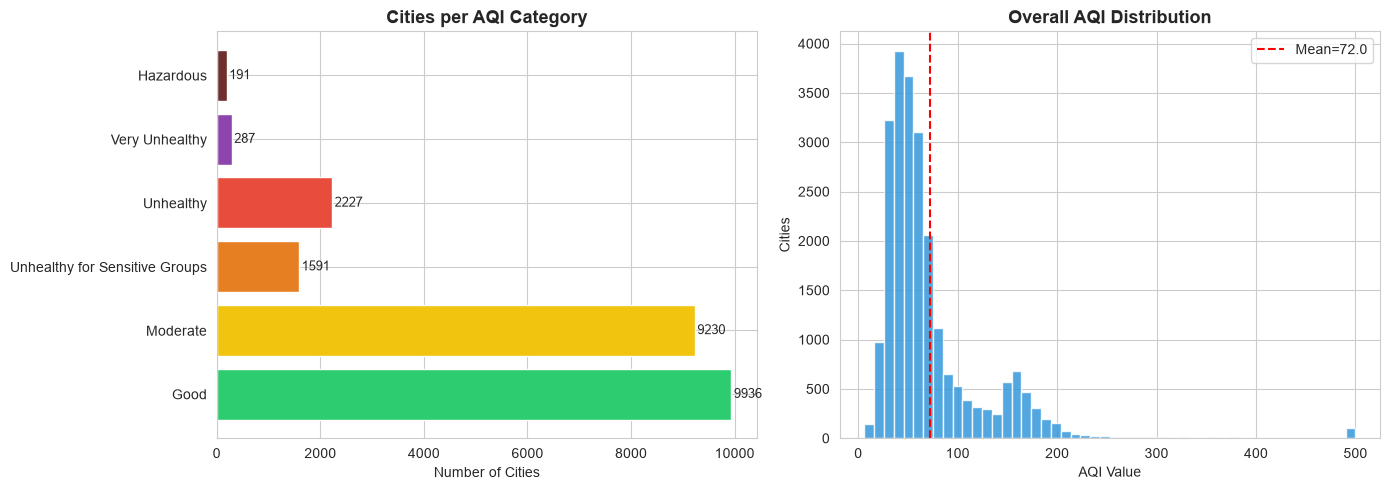

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
colors_cat = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#6e2f2f']
counts = df['AQI Category'].value_counts().reindex(cat_order, fill_value=0)

axes[0].barh(cat_order, counts.values, color=colors_cat)
axes[0].set_title('Cities per AQI Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Cities')
for i, v in enumerate(counts.values):
    axes[0].text(v+50, i, str(v), va='center', fontsize=9)

axes[1].hist(df['AQI Value'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(df['AQI Value'].mean(), color='red', linestyle='--',
                label=f"Mean={df['AQI Value'].mean():.1f}")
axes[1].set_title('Overall AQI Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AQI Value'); axes[1].set_ylabel('Cities'); axes[1].legend()
plt.tight_layout()
plt.savefig('plots/01_aqi_overview.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Correlation Heatmap

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True, mask=mask)
ax.set_title('Pollutant Correlation Heatmap (3 clustering features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AQI Value ↔ PM2.5 correlation: {df['AQI Value'].corr(df['PM2.5 AQI Value']):.4f}")
print("Note: High correlation retained — AQI Value captures max across all pollutants")
print("while PM2.5 captures the raw PM2.5 contribution specifically.")


NameError: name 'plt' is not defined

### 5.3 Top 15 Most Polluted Countries

Top 15 countries by average AQI:
                      Avg_AQI  Cities      Continent
Country                                             
Republic of Korea       421.0       1           Asia
Bahrain                 188.0       1           Asia
Mauritania              179.0       4         Africa
Pakistan                178.8     307           Asia
United Arab Emirates    163.7       3           Asia
Aruba                   163.0       1  North America
Kuwait                  162.0       3           Asia
Qatar                   157.5       2           Asia
India                   153.0    2488           Asia
Senegal                 152.4      33         Africa
Saudi Arabia            149.3      14           Asia
Gambia                  147.0       9         Africa
Yemen                   144.6       7           Asia
Guinea-Bissau           138.8       4         Africa
Oman                    137.5       6           Asia


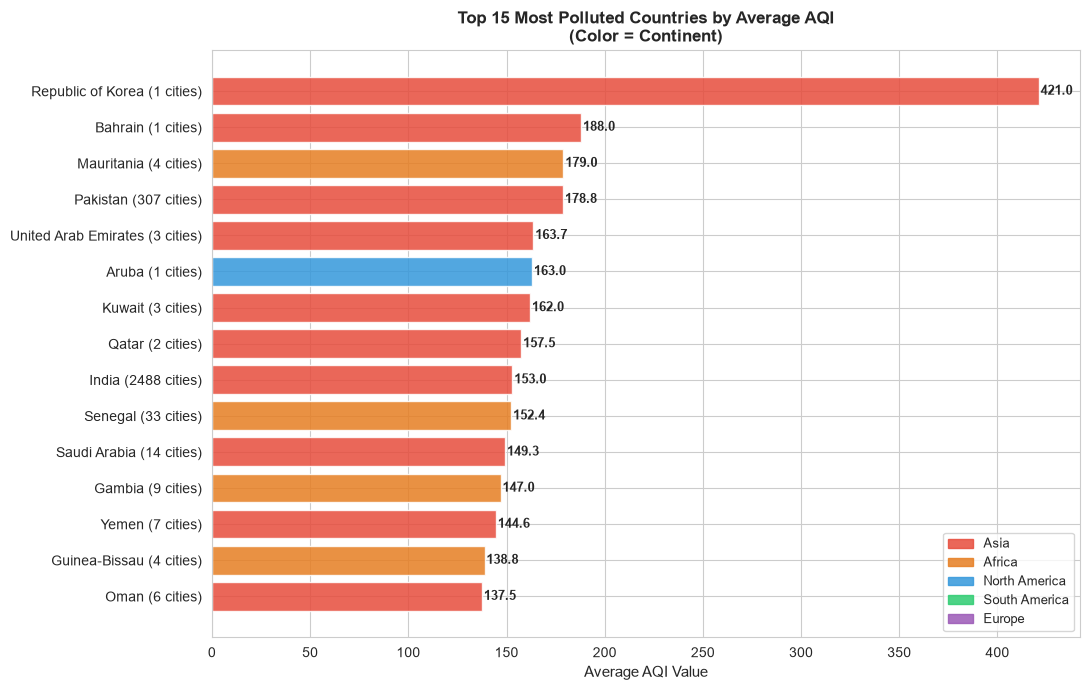

In [ ]:
country_stats = df[df['Country'] != 'Unknown'].groupby('Country').agg(
    Avg_AQI=('AQI Value', 'mean'),
    Cities=('City', 'count'),
    Continent=('Continent', 'first')
).sort_values('Avg_AQI', ascending=False).round(1)

print("Top 15 countries by average AQI:")
print(country_stats.head(15).to_string())

fig, ax = plt.subplots(figsize=(11, 7))
top15 = country_stats.head(15)
cont_colors_map = {'Asia':'#e74c3c','Africa':'#e67e22','North America':'#3498db',
                   'South America':'#2ecc71','Europe':'#9b59b6','Unknown':'#95a5a6'}
bar_colors = [cont_colors_map.get(c,'#95a5a6') for c in top15['Continent']]
bars = ax.barh(top15.index + ' (' + top15['Cities'].astype(str) + ' cities)',
               top15['Avg_AQI'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Average AQI Value', fontsize=11)
ax.set_title('Top 15 Most Polluted Countries by Average AQI\n(Color = Continent)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, v in zip(bars, top15['Avg_AQI']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=9, fontweight='bold')
legend_patches = [mpatches.Patch(color=v, label=k, alpha=0.85) for k,v in cont_colors_map.items() if k!='Unknown']
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('plots/H_top15_countries.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Selection & Standard Scaling

Final clustering inputs:

- `Ozone AQI Value`
- `NO2 AQI Value`
- `PM2.5 AQI Value`

`AQI Value` is deliberately excluded from the distance calculation because it is an overall AQI summary. It will be used later to interpret the clusters.


In [ ]:
features = [
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Selected features:", features)
print("\nBefore scaling:")
print(df[features].describe().loc[["min", "max", "mean", "std"]].round(2))
print("\nAfter scaling:")
print(pd.DataFrame(X_scaled, columns=features).describe().loc[["mean", "std"]].round(3))


Selected features: ['Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

Before scaling:
      Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
min              0.00           0.00             0.00
max            235.00          91.00           500.00
mean            35.19           3.06            68.52
std             28.10           5.25            54.80

After scaling:
      Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
mean             -0.0            0.0              0.0
std               1.0            1.0              1.0


## 7. Finding Optimal K — WCSS + Silhouette + Davies-Bouldin + Calinski-Harabasz

No single metric is treated as an automatic answer. We compare several diagnostics and select K transparently.

Because silhouette requires pairwise distances, its K-search value is computed on a reproducible sample of up to 5,000 cities.


In [ ]:
# Sensitivity check: K=4 with and without CO
comparison_features = {
    "Without CO (final)": features,
    "With CO": features + ["CO AQI Value"]
}

co_comparison = []

for label, feature_set in comparison_features.items():
    comparison_scaler = StandardScaler()
    X_compare = comparison_scaler.fit_transform(df[feature_set])

    comparison_model = KMeans(
        n_clusters=4,
        random_state=42,
        n_init=20
    )
    comparison_labels = comparison_model.fit_predict(X_compare)

    co_comparison.append({
        "Feature Set": label,
        "Silhouette": silhouette_score(X_compare, comparison_labels),
        "Davies-Bouldin": davies_bouldin_score(X_compare, comparison_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_compare, comparison_labels)
    })

co_comparison = pd.DataFrame(co_comparison)
display(co_comparison.round(4))

print(
    "Interpretation: adding CO slightly increases Silhouette, "
    "but worsens Davies-Bouldin and Calinski-Harabasz. "
    "Given CO's extreme skew and low variation for most cities, "
    "the final model excludes CO."
)


In [ ]:
# K Selection — Multiple Diagnostics
K_range = range(2, 9)

sample_size = min(5000, len(X_scaled))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), sample_size, replace=False)

k_results = []

for k in K_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km_k.fit_predict(X_scaled)

    k_results.append({
        "K": k,
        "WCSS": km_k.inertia_,
        "Silhouette_sample": silhouette_score(
            X_scaled[sample_idx], labels[sample_idx]
        ),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

k_results = pd.DataFrame(k_results)
display(k_results.round(4))

# WCSS is used for elbow analysis.
# The combined rank uses the three quality metrics below.
ranked = k_results.copy()
ranked["Rank_Silhouette"] = ranked["Silhouette_sample"].rank(
    ascending=False, method="min"
)
ranked["Rank_DBI"] = ranked["Davies_Bouldin"].rank(
    ascending=True, method="min"
)
ranked["Rank_CH"] = ranked["Calinski_Harabasz"].rank(
    ascending=False, method="min"
)
ranked["Combined_Rank"] = (
    ranked["Rank_Silhouette"] +
    ranked["Rank_DBI"] +
    ranked["Rank_CH"]
)

display(
    ranked[[
        "K",
        "Rank_Silhouette",
        "Rank_DBI",
        "Rank_CH",
        "Combined_Rank"
    ]].sort_values(["Combined_Rank", "K"])
)

# K=3, K=4 and K=6 tie on the combined rank.
# K=4 is selected for interpretability and profile granularity:
# it separates NO2-dominant and PM2.5-dominant cities without the
# additional complexity of the six-cluster solution.
chosen_k = 4

print(f"Selected K = {chosen_k}")
print(
    "Reason: K=3, K=4 and K=6 tie on the combined rank of "
    "Silhouette, Davies-Bouldin and Calinski-Harabasz. "
    "K=4 provides four substantial, interpretable pollutant profiles "
    "and a useful balance between granularity and complexity."
)


,K,WCSS,Silhouette_sample,Davies_Bouldin,Calinski_Harabasz
0,2,48651.3306,0.6620,0.8351,10480.6043
1,3,31632.9957,0.5972,0.7844,14369.6091
2,4,24680.9492,0.5749,0.7982,14480.1257
3,5,20682.0785,0.4461,0.8543,14093.1910
4,6,17300.3473,0.4539,0.7804,14394.8883
5,7,15121.1211,0.3005,0.8828,14287.6560
6,8,13338.1471,0.3135,0.8796,14330.5715


,K,Rank_Silhouette,Rank_DBI,Rank_CH,Combined_Rank
1,3,2.0,2.0,3.0,7.0
2,4,3.0,3.0,1.0,7.0
4,6,4.0,1.0,2.0,7.0
0,2,1.0,4.0,7.0,12.0
3,5,5.0,5.0,6.0,16.0
6,8,6.0,6.0,4.0,16.0
5,7,7.0,7.0,5.0,19.0


Selected K = 4
Reason: K=4 provides a meaningful and interpretable four-profile
pollution segmentation while retaining strong clustering quality.


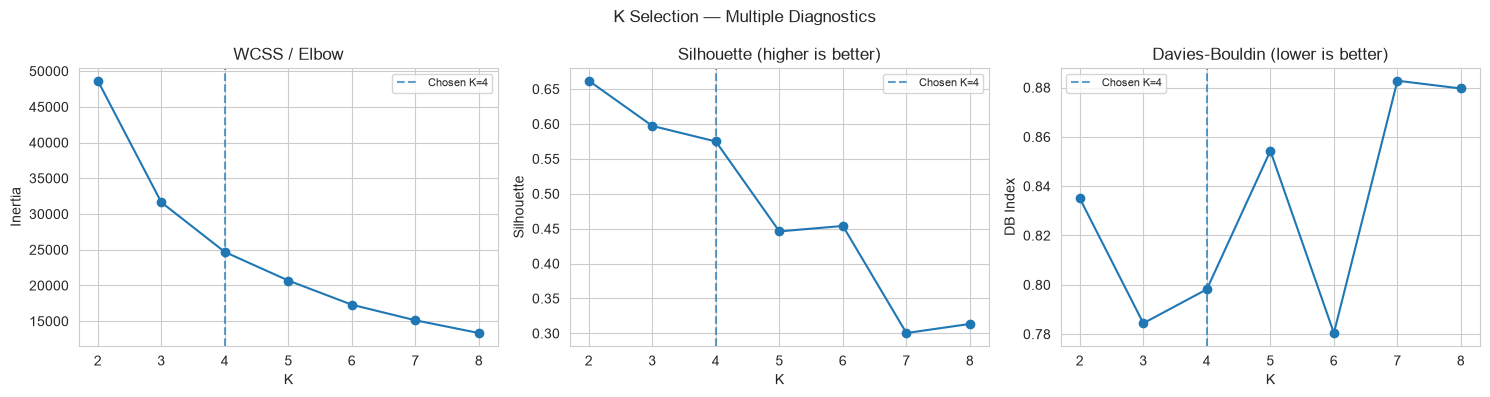

In [ ]:
# Visual comparison of K-selection diagnostics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_results["K"], k_results["WCSS"], "o-")
axes[0].set_title("WCSS / Elbow")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_results["K"], k_results["Silhouette_sample"], "o-")
axes[1].set_title("Silhouette (higher is better)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")

axes[2].plot(k_results["K"], k_results["Davies_Bouldin"], "o-")
axes[2].set_title("Davies-Bouldin (lower is better)")
axes[2].set_xlabel("K")
axes[2].set_ylabel("DB Index")

for ax in axes:
    ax.axvline(
        chosen_k,
        linestyle="--",
        alpha=0.7,
        label=f"Chosen K={chosen_k}"
    )
    ax.legend(fontsize=8)

plt.suptitle("K Selection — Multiple Diagnostics")
plt.tight_layout()
plt.savefig("plots/03_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. K-Means Clustering

The final K-Means model uses the K selected above. Cluster names are assigned after fitting from the observed centroid profiles; they are descriptive labels, not model inputs.


In [ ]:
# Final K-Means model
km_final = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=20
)

df["KMeans_Cluster"] = km_final.fit_predict(X_scaled)

# Cluster profile statistics on the original AQI scale.
centroids = df.groupby("KMeans_Cluster")[features].mean()
centroids["Cluster_Avg_AQI"] = (
    df.groupby("KMeans_Cluster")["AQI Value"].mean()
)
centroids["Cities"] = df["KMeans_Cluster"].value_counts()

# Assign descriptive names based on the actual pollutant profiles.
cluster_names = {}

lowest_aqi_cluster = centroids["Cluster_Avg_AQI"].idxmin()
cluster_names[lowest_aqi_cluster] = "Lower Pollution Profile"

remaining = [c for c in centroids.index if c != lowest_aqi_cluster]

highest_ozone_cluster = centroids.loc[remaining, "Ozone AQI Value"].idxmax()
cluster_names[highest_ozone_cluster] = "Ozone + PM2.5 Dominant Profile"

remaining = [c for c in remaining if c != highest_ozone_cluster]

highest_no2_cluster = centroids.loc[remaining, "NO2 AQI Value"].idxmax()
cluster_names[highest_no2_cluster] = "NO2-Dominant Profile"

remaining = [c for c in remaining if c != highest_no2_cluster]

cluster_names[remaining[0]] = "PM2.5-Dominant Profile"

df["Cluster_Name"] = df["KMeans_Cluster"].map(cluster_names)

sil = silhouette_score(X_scaled, df["KMeans_Cluster"])
dbi = davies_bouldin_score(X_scaled, df["KMeans_Cluster"])
chi = calinski_harabasz_score(X_scaled, df["KMeans_Cluster"])

print("=== Final K-Means Evaluation ===")
print(f"Selected K           : {chosen_k}")
print(f"Silhouette Score     : {sil:.4f}")
print(f"Davies-Bouldin Index : {dbi:.4f}")
print(f"Calinski-Harabasz    : {chi:.2f}")

summary = df.groupby("Cluster_Name")[features].mean().round(1)
summary["Average AQI"] = (
    df.groupby("Cluster_Name")["AQI Value"].mean().round(1)
)
summary["Cities"] = df["Cluster_Name"].value_counts()

display(summary)

print("\nCluster names:")
for cluster_id, name in cluster_names.items():
    print(f"  Cluster {cluster_id}: {name}")

=== Final K-Means Evaluation ===
Selected K           : 4
Silhouette Score     : 0.5595
Davies-Bouldin Index : 0.7982
Calinski-Harabasz    : 14480.13


,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,Average AQI,Cities
Cluster_Name,,,,,
Lower Pollution Profile,30.4,1.8,47.9,51.0,18529
NO2-Dominant Profile,15.3,17.5,108.1,108.1,1807
Ozone + PM2.5 Dominant Profile,143.9,2.6,154.5,171.0,1020
PM2.5-Dominant Profile,42.2,2.1,174.5,177.9,2106



Cluster names:
  Cluster 1: Lower Pollution Profile
  Cluster 2: Ozone + PM2.5 Dominant Profile
  Cluster 3: NO2-Dominant Profile
  Cluster 0: PM2.5-Dominant Profile


## 8.1 Box Plots per Cluster

These plots show the within-cluster spread of each pollutant-specific AQI feature.


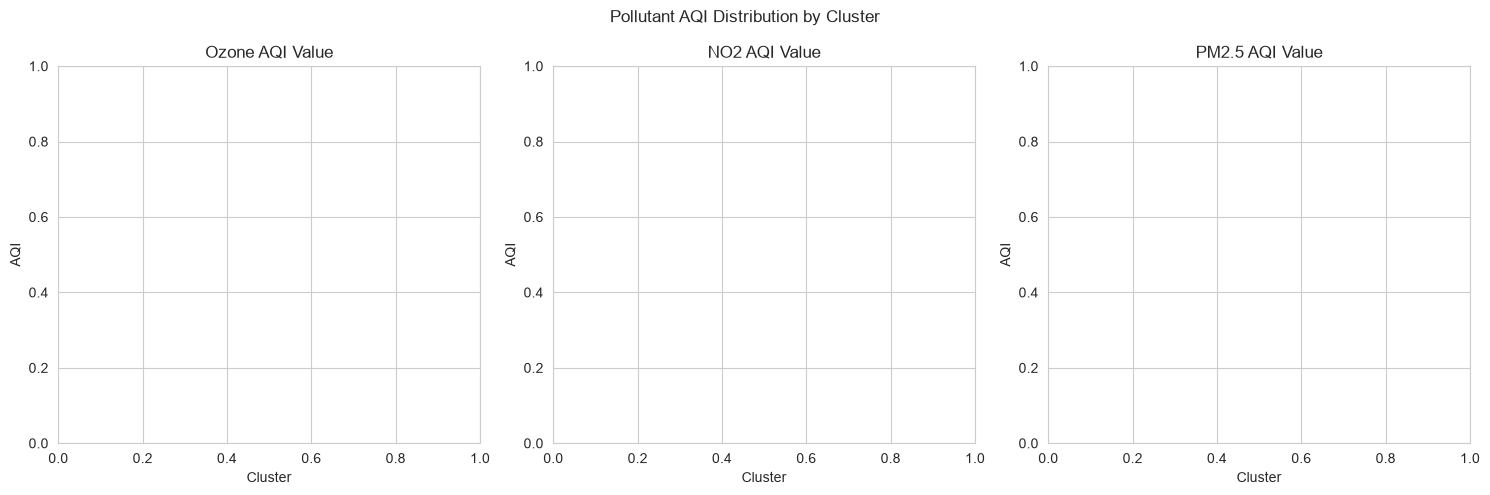

In [ ]:
poll_feats = features
cluster_order = list(cluster_names.values())

fig, axes = plt.subplots(1, len(poll_feats), figsize=(15, 5))
if len(poll_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, poll_feats):
    data = [df.loc[df["Cluster_Name"] == name, feat].values for name in cluster_order]

   #This avoids the `labels` keyword error and still names each boxplot by cluster.
    ax.set_title(feat)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("AQI")

plt.suptitle("Pollutant AQI Distribution by Cluster")
plt.tight_layout()
plt.show()


### 8.2 Centroid Heatmap

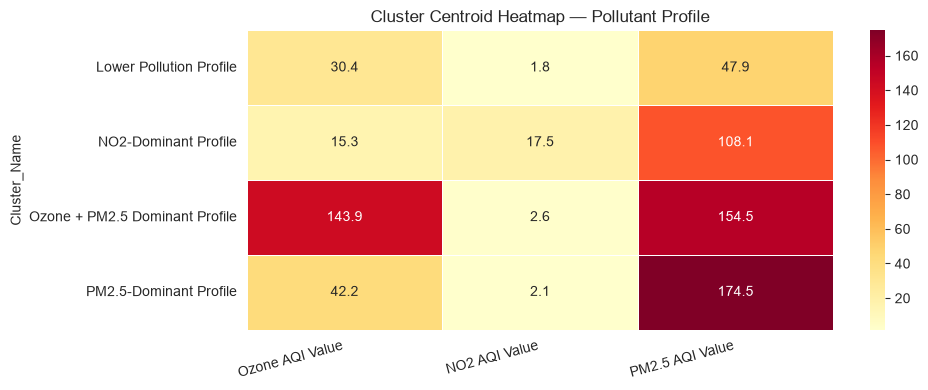

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
heat = df.groupby("Cluster_Name")[features].mean().round(1)
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Cluster Centroid Heatmap — Pollutant Profile")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("plots/04_centroid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.3 Radar Chart

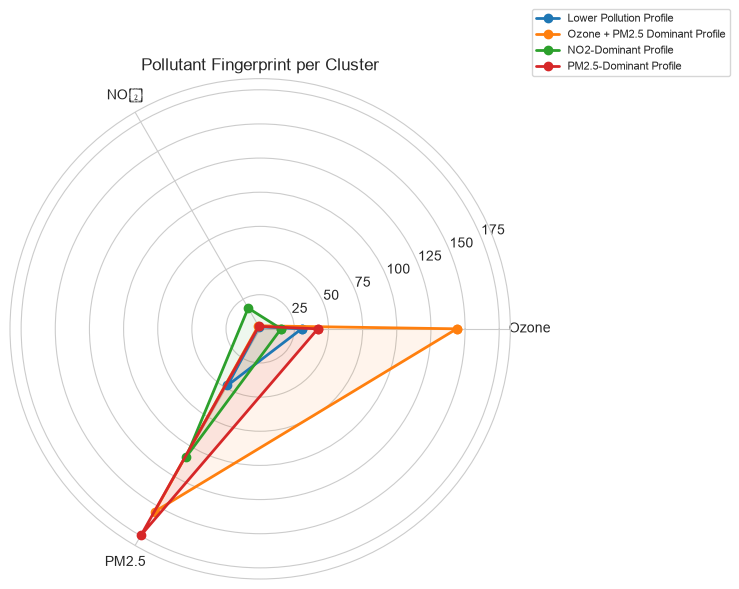

In [ ]:
radar_feats = features
N = len(radar_feats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for i, name in enumerate(cluster_names.values()):
    vals = df.loc[df["Cluster_Name"] == name, radar_feats].mean().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=name)
    ax.fill(angles, vals, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Ozone", "NO₂", "PM2.5"])
ax.set_title("Pollutant Fingerprint per Cluster")
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), fontsize=8)
plt.tight_layout()
plt.show()


## 9. PCA — Loadings Interpretation

PCA is used for visualization and dimensionality interpretation. The loading values are calculated from the current dataset, so no hard-coded interpretation is assumed.


In [ ]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
df["PC3"] = X_pca[:, 2]

loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PC1", "PC2", "PC3"]
)

print("PCA feature loadings:")
display(loadings.round(4))

print(
    f"PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%"
)
print(
    f"PC2 variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%"
)
print(
    f"PC3 variance explained: {pca.explained_variance_ratio_[2]*100:.1f}%"
)
print(
    f"PC1 + PC2 + PC3: {pca.explained_variance_ratio_.sum()*100:.1f}%"
)


PCA feature loadings:


,PC1,PC2,PC3
Ozone AQI Value,0.6008,-0.5464,-0.5835
NO2 AQI Value,0.2494,0.8216,-0.5126
PM2.5 AQI Value,0.7595,0.1624,0.6299


PC1 variance explained: 45.1%
PC2 variance explained: 39.1%
PC3 variance explained: 15.8%
PC1 + PC2 + PC3: 100.0%


AttributeError: 'Axes' object has no attribute 'set_zlabel'

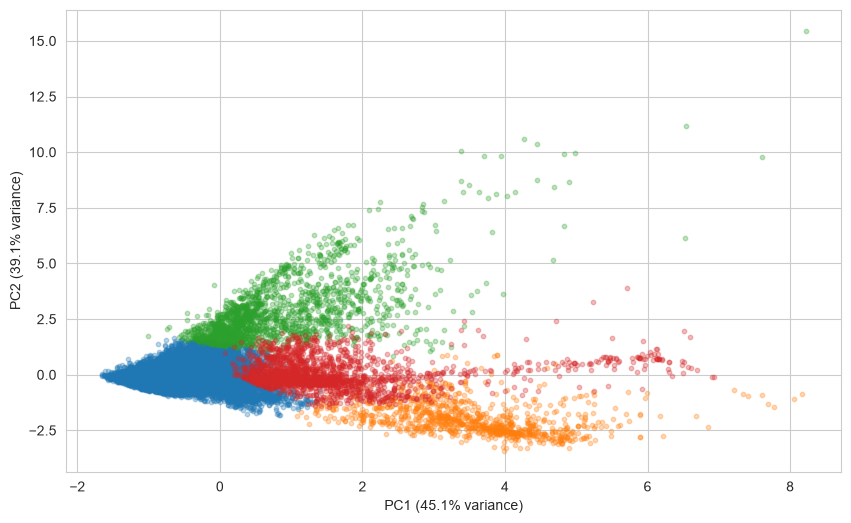

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cluster_id, name in cluster_names.items():
    mask = df["KMeans_Cluster"] == cluster_id
    ax.scatter(
        df.loc[mask, "PC1"],
        df.loc[mask, "PC2"],
        alpha=0.3,
        s=10,
        label=name
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
# This is a 2D PCA plot, so no z-axis label is needed.
ax.set_title("PCA Projection of K-Means Clusters")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plots/05_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.1 3D PCA Projection (New in v3)

3D PCA variance: PC1=45.1%, PC2=39.1%, PC3=15.8%, Total=100.0%


FileNotFoundError: [Errno 2] No such file or directory: 'plots/J_pca_3d.png'

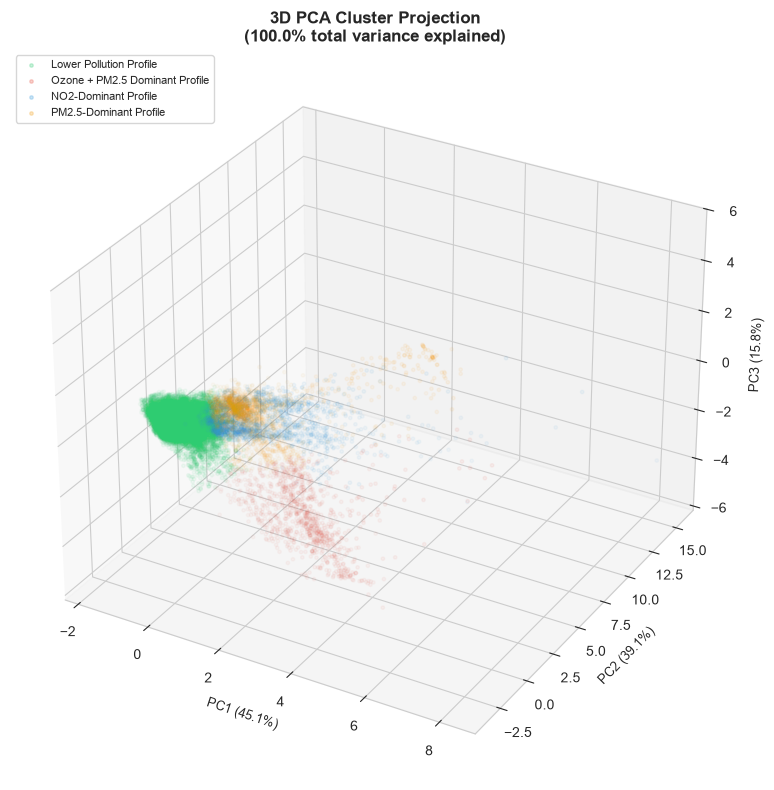

In [ ]:
var3 = pca.explained_variance_ratio_ * 100
print(f"3D PCA variance: PC1={var3[0]:.1f}%, PC2={var3[1]:.1f}%, PC3={var3[2]:.1f}%, Total={sum(var3[:3]):.1f}%")

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
COLORS = {
    'Lower Pollution Profile': '#2ecc71',
    'Ozone + PM2.5 Dominant Profile': '#e74c3c',
    'NO2-Dominant Profile': '#3498db',
    'PM2.5-Dominant Profile': '#f39c12'     
}

for name, color in COLORS.items():
    mask = df['Cluster_Name'] == name
    ax.scatter(df.loc[mask,'PC1'], df.loc[mask,'PC2'], df.loc[mask,'PC3'],
               c=color, label=name.split('/')[0], alpha=0.25, s=6)
ax.set_xlabel(f'PC1 ({var3[0]:.1f}%)', fontsize=9)
ax.set_ylabel(f'PC2 ({var3[1]:.1f}%)', fontsize=9)
ax.set_zlabel(f'PC3 ({var3[2]:.1f}%)', fontsize=9)
ax.set_title(f'3D PCA Cluster Projection\n({sum(var3[:3]):.1f}% total variance explained)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('plots/J_pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Silhouette Analysis — Per City and Per Cluster

Per-city silhouette values identify observations close to cluster boundaries. Negative values indicate that a city is, by this metric, closer to another cluster than its assigned cluster.


In [ ]:
sil_vals = silhouette_samples(X_scaled, df["KMeans_Cluster"])
df["Sil_Sample"] = sil_vals

sil_summary = df.groupby("Cluster_Name")["Sil_Sample"].agg(
    Mean="mean",
    Std="std",
    Negative_Pct=lambda s: (s < 0).mean() * 100,
    Cities="size"
).round(3)

display(sil_summary)

print(f"Overall Silhouette Score: {silhouette_score(X_scaled, df['KMeans_Cluster']):.4f}")
print(f"Negative silhouette cities: {(sil_vals < 0).sum():,} "
      f"({(sil_vals < 0).mean()*100:.2f}%)")


,Mean,Std,Negative_Pct,Cities
Cluster_Name,,,,
Lower Pollution Profile,0.619,0.133,0.000,18529
NO2-Dominant Profile,0.304,0.185,8.301,1807
Ozone + PM2.5 Dominant Profile,0.497,0.190,0.784,1020
PM2.5-Dominant Profile,0.284,0.169,8.120,2106


Overall Silhouette Score: 0.5595
Negative silhouette cities: 329 (1.40%)


### 10.1 Silhouette Plot — Per-City Bars (New in v3)

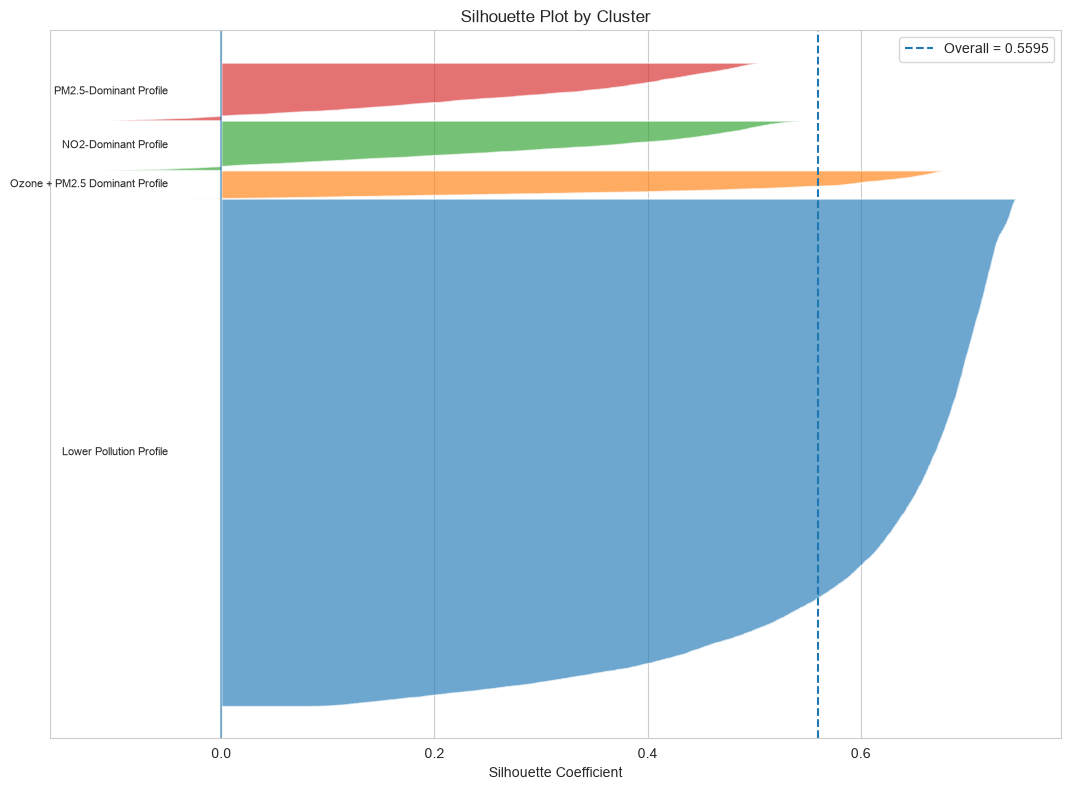

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))
y_lower = 10
overall_sil = silhouette_score(X_scaled, df["KMeans_Cluster"])

for cluster_id, name in cluster_names.items():
    mask = df["KMeans_Cluster"] == cluster_id
    vals = np.sort(df.loc[mask, "Sil_Sample"].values)
    size = len(vals)
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, vals,
        alpha=0.65
    )
    ax.text(-0.05, y_lower + size/2, name,
            ha="right", va="center", fontsize=8)
    y_lower = y_upper + 10

ax.axvline(
    overall_sil, linestyle="--",
    label=f"Overall = {overall_sil:.4f}"
)
ax.axvline(0, linestyle="-", alpha=0.5)

ax.set_xlabel("Silhouette Coefficient")
ax.set_title("Silhouette Plot by Cluster")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


### 10.2 Per-Cluster Silhouette Summary

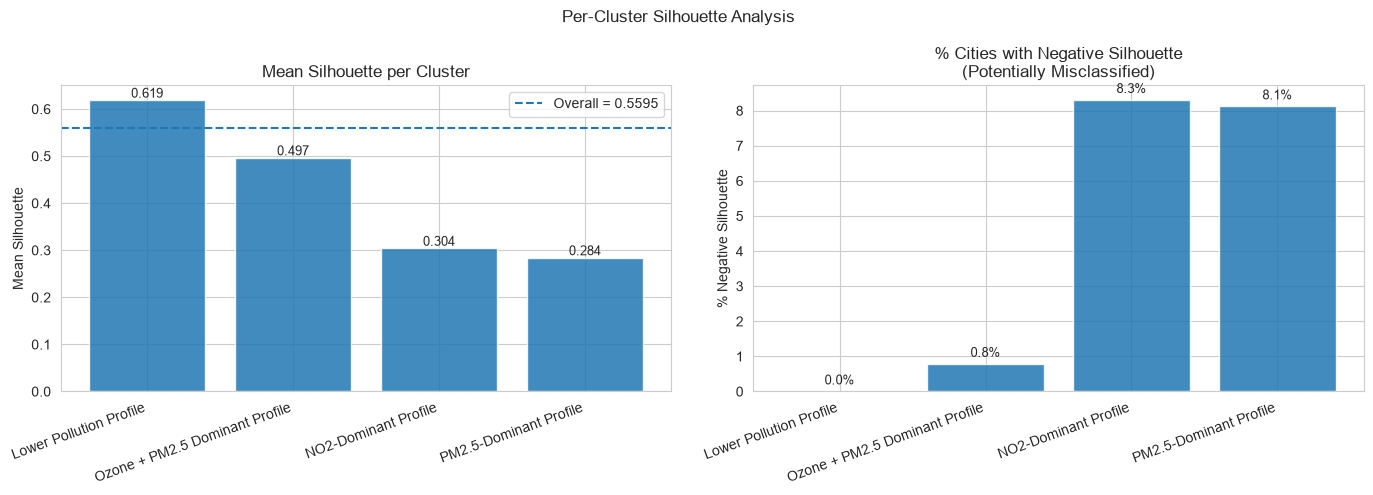

In [ ]:
# Per-cluster silhouette analysis
cluster_order = list(cluster_names.values())

means = [
    df.loc[df["Cluster_Name"] == name, "Sil_Sample"].mean()
    for name in cluster_order
]

neg_pct = [
    (df.loc[df["Cluster_Name"] == name, "Sil_Sample"] < 0).mean() * 100
    for name in cluster_order
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(cluster_order, means, alpha=0.85, edgecolor="white")
axes[0].axhline(
    overall_sil,
    linestyle="--",
    label=f"Overall = {overall_sil:.4f}"
)
axes[0].set_title("Mean Silhouette per Cluster")
axes[0].set_ylabel("Mean Silhouette")
axes[0].legend()
plt.setp(
    axes[0].xaxis.get_majorticklabels(),
    rotation=20,
    ha="right"
)

for bar, value in zip(bars, means):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{value:.3f}",
        ha="center",
        fontsize=9
    )

bars2 = axes[1].bar(cluster_order, neg_pct, alpha=0.85, edgecolor="white")
axes[1].set_title(
    "% Cities with Negative Silhouette\n(Potentially Misclassified)"
)
axes[1].set_ylabel("% Negative Silhouette")
plt.setp(
    axes[1].xaxis.get_majorticklabels(),
    rotation=20,
    ha="right"
)

for bar, value in zip(bars2, neg_pct):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.suptitle("Per-Cluster Silhouette Analysis")
plt.tight_layout()
plt.savefig("plots/E_per_cluster_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.3 Borderline Cities Analysis (New in v3)

In [ ]:
borderline = df[(df['Sil_Sample'] >= -0.1) & (df['Sil_Sample'] <= 0.05)].copy()
borderline_sorted = borderline.sort_values('Sil_Sample').head(30)

print(f"Borderline cities (silhouette between -0.1 and 0.05): {len(borderline)}")
print("These cities sit on the boundary between two clusters.")
print()
print("Top 30 most ambiguous cities:")
print(borderline_sorted[['Country','City','Continent','Cluster_Name',
                          'Sil_Sample','AQI Value','Ozone AQI Value',
                          'NO2 AQI Value','PM2.5 AQI Value']].to_string(index=False))
print()
print("Which cluster produces the most borderline cities?")
print(borderline['Cluster_Name'].value_counts().to_string())


Borderline cities (silhouette between -0.1 and 0.05): 524
These cities sit on the boundary between two clusters.

Top 30 most ambiguous cities:
                                             Country                City     Continent           Cluster_Name  Sil_Sample  AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
                                               India               Sopur          Asia PM2.5-Dominant Profile   -0.098345        108               49              0              108
                            United States of America               Berea North America   NO2-Dominant Profile   -0.098075         68               22             10               68
                                              Mexico             Atlixco North America   NO2-Dominant Profile   -0.097882        118               13              8              118
                                  Dominican Republic    Villa Altagracia North America PM2.5-Dominant Profile   -0.097860       

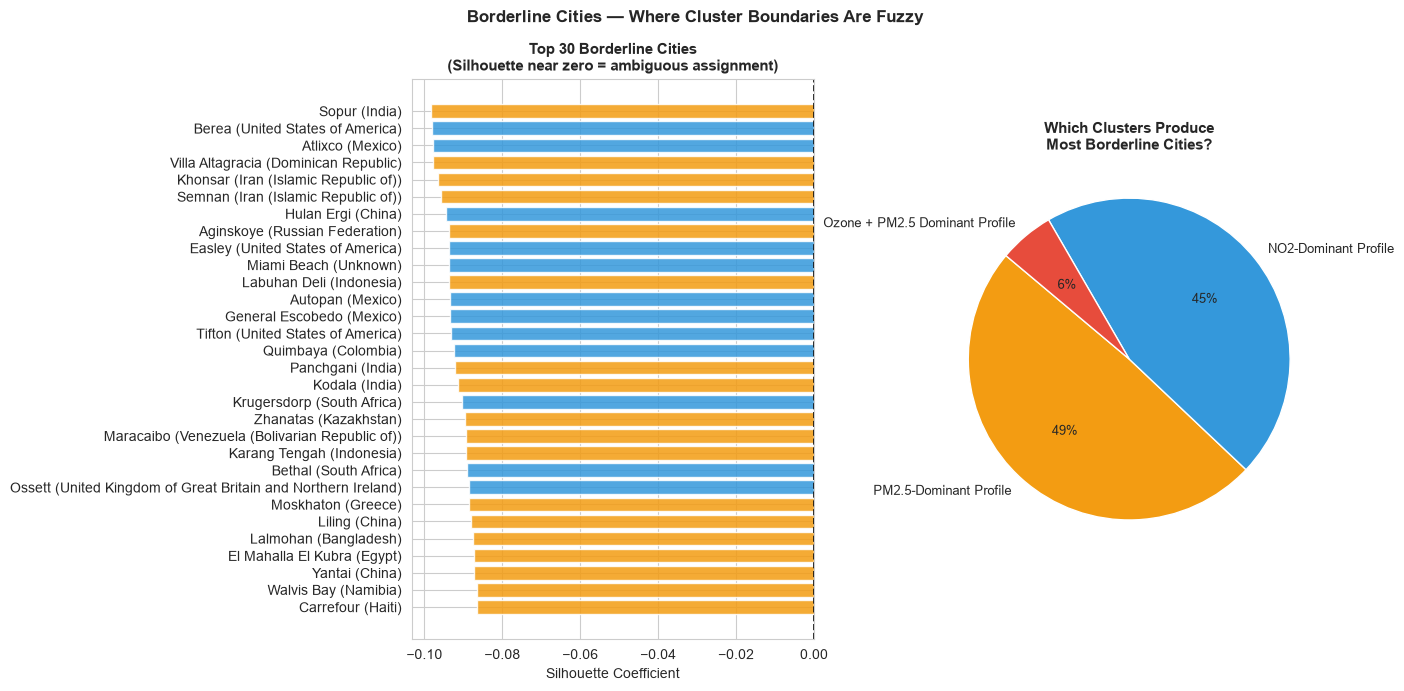

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

bl_colors = [COLORS.get(n,'#999') for n in borderline_sorted['Cluster_Name']]
axes[0].barh(borderline_sorted['City']+' ('+borderline_sorted['Country'].fillna('?')+')',
             borderline_sorted['Sil_Sample'], color=bl_colors, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_title('Top 30 Borderline Cities\n(Silhouette near zero = ambiguous assignment)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Silhouette Coefficient')
axes[0].invert_yaxis()

bl_cluster_counts = borderline['Cluster_Name'].value_counts()
bl_colors_pie = [COLORS.get(n,'#999') for n in bl_cluster_counts.index]
axes[1].pie(bl_cluster_counts.values,
            labels=[n.split('/')[0] for n in bl_cluster_counts.index],
            colors=bl_colors_pie, autopct='%1.0f%%', startangle=140, textprops={'fontsize':9})
axes[1].set_title('Which Clusters Produce\nMost Borderline Cities?', fontsize=11, fontweight='bold')

plt.suptitle('Borderline Cities — Where Cluster Boundaries Are Fuzzy',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/G_borderline_cities.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Cluster Stability Analysis

The final K-Means configuration is re-fitted with 10 different random seeds.
Silhouette is evaluated on a reproducible 5,000-city sample for each seed.

The purpose is to check whether the discovered structure is sensitive to K-Means
initialisation rather than to claim that every random seed produces identical labels.


In [ ]:
seed_sils, seed_dbs = [], []

for seed in range(10):
    km = KMeans(n_clusters=chosen_k, random_state=seed, n_init=20)
    labels = km.fit_predict(X_scaled)

    rng_seed = np.random.RandomState(seed)
    idx = rng_seed.choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)

    seed_sils.append(silhouette_score(X_scaled[idx], labels[idx]))
    seed_dbs.append(davies_bouldin_score(X_scaled, labels))

print(f"Silhouette mean: {np.mean(seed_sils):.4f}")
print(f"Silhouette std : {np.std(seed_sils):.4f}")
print(f"DBI mean       : {np.mean(seed_dbs):.4f}")
print(f"DBI std        : {np.std(seed_dbs):.4f}")


Silhouette mean: 0.5606
Silhouette std : 0.0056
DBI mean       : 0.7982
DBI std        : 0.0000


## 12. DBSCAN — Parameter Tuning

`eps=0.5` is not assumed. A grid from 0.25 to 1.00 is evaluated with
`min_samples=10`. The selected configuration maximises Silhouette on non-noise
points while keeping the noise rate below 50%.

DBSCAN noise points are density-based outliers: their pollutant combinations do not
fit the learned density structure. They should not automatically be interpreted as
pollution events or data errors.


In [ ]:
eps_values = np.arange(0.25, 1.01, 0.05)
dbscan_results = []

for eps in eps_values:
    model = DBSCAN(eps=float(eps), min_samples=10)
    labels = model.fit_predict(X_scaled)

    non_noise = labels != -1
    n_clusters = len(set(labels[non_noise]))

    sil_db = (
        silhouette_score(X_scaled[non_noise], labels[non_noise])
        if n_clusters >= 2 and non_noise.sum() > 1
        else np.nan
    )

    dbscan_results.append({
        "eps": round(float(eps), 2),
        "clusters": n_clusters,
        "noise_pct": (~non_noise).mean() * 100,
        "silhouette_non_noise": sil_db
    })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results.round(3))

valid = dbscan_results.dropna(subset=["silhouette_non_noise"])
reasonable = valid[valid["noise_pct"] < 50]

if len(reasonable):
    best_eps = float(
        reasonable.sort_values(
            ["silhouette_non_noise", "noise_pct"],
            ascending=[False, True]
        ).iloc[0]["eps"]
    )
else:
    best_eps = float(
        valid.sort_values("silhouette_non_noise", ascending=False).iloc[0]["eps"]
    )

print(f"Selected eps: {best_eps:.2f}")

db_model = DBSCAN(eps=best_eps, min_samples=10)
df["DBSCAN_Cluster"] = db_model.fit_predict(X_scaled)

n_clusters = df.loc[df["DBSCAN_Cluster"] != -1, "DBSCAN_Cluster"].nunique()
n_noise = (df["DBSCAN_Cluster"] == -1).sum()

print(f"DBSCAN clusters: {n_clusters}")
print(f"Noise cities: {n_noise:,} ({n_noise/len(df)*100:.2f}%)")


,eps,clusters,noise_pct,silhouette_non_noise
0,0.25,10,4.816,0.387
1,0.30,8,2.949,0.529
2,0.35,5,2.080,0.356
3,0.40,3,1.662,0.695
4,0.45,6,1.151,0.505
5,0.50,4,0.857,0.506
6,0.55,2,0.759,0.675
7,0.60,1,0.618,NaN
8,0.65,1,0.554,NaN
9,0.70,1,0.486,NaN


Selected eps: 0.85
DBSCAN clusters: 2
Noise cities: 75 (0.32%)


### 12.1 DBSCAN Results


In [ ]:
outliers = df[df["DBSCAN_Cluster"] == -1].copy()

print(f"DBSCAN identified {len(outliers):,} noise cities.")
if len(outliers):
    display(
        outliers.nlargest(15, "AQI Value")[[
            "Country", "City", "AQI Value", "AQI Category",
            "Ozone AQI Value", "NO2 AQI Value", "PM2.5 AQI Value"
        ]]
    )


DBSCAN identified 75 noise cities.


,Country,City,AQI Value,AQI Category,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
720,India,Kandhla,500,Hazardous,53,8,500
1561,India,Dataganj,500,Hazardous,61,9,437
5156,United States of America,Durango,500,Hazardous,0,53,500
6786,India,Aonla,500,Hazardous,149,4,479
10851,India,Dhanaura,500,Hazardous,143,4,428
10926,India,Tikri,500,Hazardous,47,9,500
13604,India,Puranpur,500,Hazardous,128,1,481
18160,South Africa,Boksburg,500,Hazardous,1,30,500
18598,India,Palia Kalan,500,Hazardous,152,1,456
18681,India,Mailani,500,Hazardous,116,1,471


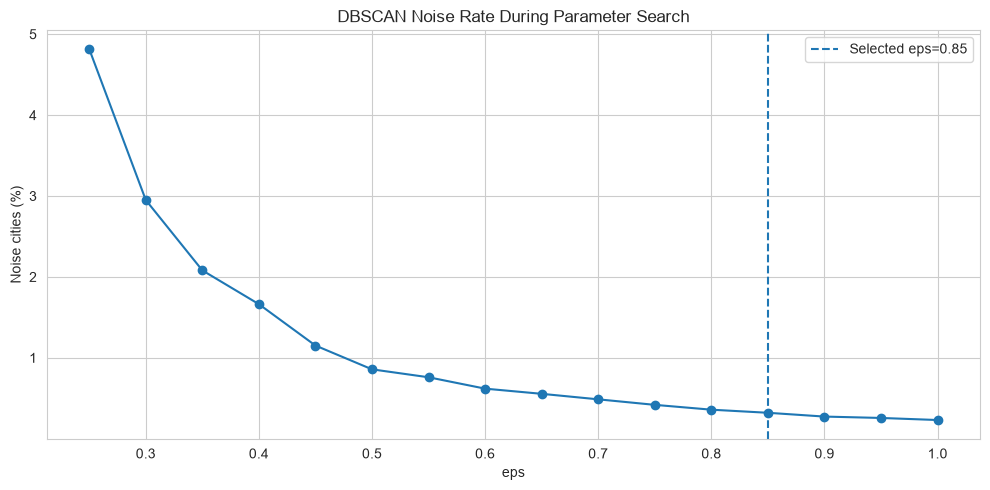

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dbscan_results["eps"], dbscan_results["noise_pct"], "o-")
ax.axvline(best_eps, linestyle="--", label=f"Selected eps={best_eps:.2f}")
ax.set_xlabel("eps")
ax.set_ylabel("Noise cities (%)")
ax.set_title("DBSCAN Noise Rate During Parameter Search")
ax.legend()
plt.tight_layout()
plt.show()


## 13. External Validation Against Existing AQI Categories

`AQI Category` was not used as a clustering feature. We compare it with the discovered clusters only after fitting the unsupervised model.

This is **post-hoc validation/alignment**, not ground truth.


Counts:


AQI Category,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,Hazardous
Cluster_Name,,,,,,
Lower Pollution Profile,9881,8258,390,0,0,0
NO2-Dominant Profile,55,951,312,419,59,11
Ozone + PM2.5 Dominant Profile,0,12,220,656,109,23
PM2.5-Dominant Profile,0,9,669,1152,119,157


Row percentages:


AQI Category,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,Hazardous
Cluster_Name,,,,,,
Lower Pollution Profile,53.3,44.6,2.1,0.0,0.0,0.0
NO2-Dominant Profile,3.0,52.6,17.3,23.2,3.3,0.6
Ozone + PM2.5 Dominant Profile,0.0,1.2,21.6,64.3,10.7,2.3
PM2.5-Dominant Profile,0.0,0.4,31.8,54.7,5.7,7.5


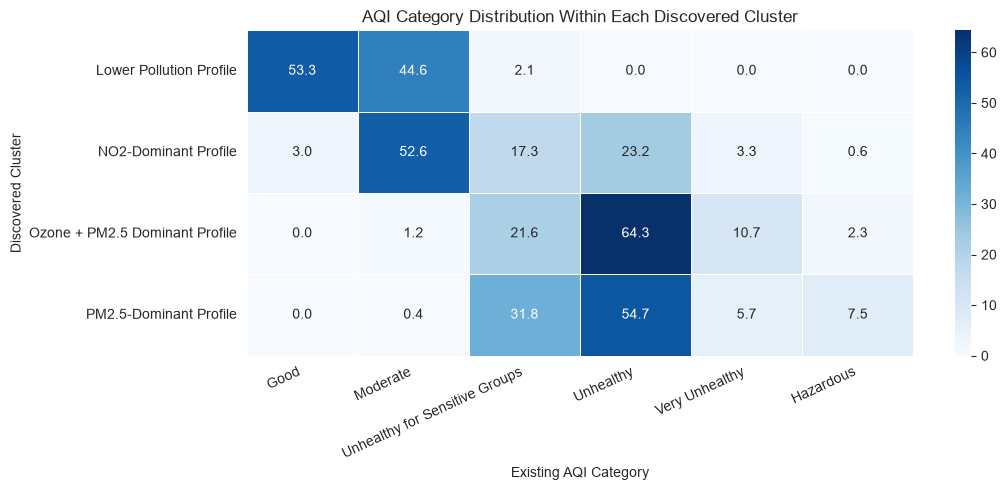

In [ ]:
cat_order = [
    "Good", "Moderate", "Unhealthy for Sensitive Groups",
    "Unhealthy", "Very Unhealthy", "Hazardous"
]

ct = pd.crosstab(df["Cluster_Name"], df["AQI Category"])
ct = ct.reindex(columns=[c for c in cat_order if c in ct.columns], fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Counts:")
display(ct)

print("Row percentages:")
display(ct_pct.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title("AQI Category Distribution Within Each Discovered Cluster")
ax.set_xlabel("Existing AQI Category")
ax.set_ylabel("Discovered Cluster")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("plots/08_external_validation.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Final Summary


In [ ]:
# Final Project Summary
sil_final = silhouette_score(X_scaled, df["KMeans_Cluster"])
dbi_final = davies_bouldin_score(X_scaled, df["KMeans_Cluster"])
chi_final = calinski_harabasz_score(X_scaled, df["KMeans_Cluster"])

print("=" * 72)
print("GLOBAL AIR POLLUTION CLUSTERING — FINAL SUMMARY")
print("=" * 72)
print(f"Dataset rows used : {len(df):,}")
print(f"Features          : {features}")
print(f"Selected K        : {chosen_k}")
print()
print("K-Means metrics:")
print(f"  Silhouette       : {sil_final:.4f}")
print(f"  Davies-Bouldin   : {dbi_final:.4f}")
print(f"  Calinski-H       : {chi_final:.2f}")
print()
print("DBSCAN:")
print(f"  eps              : {best_eps:.2f}")
print(f"  clusters         : {n_clusters}")
print(f"  noise            : {n_noise:,} ({n_noise/len(df)*100:.2f}%)")
print()
print("Key methodological decisions:")
print("  1. Pollutant-specific AQI variables are used for clustering.")
print("  2. Overall AQI is used for interpretation, not as an input feature.")
print("  3. CO is audited and excluded because of extreme skew and low variation.")
print("  4. CO sensitivity analysis is reported without relying on a single metric.")
print("  5. WCSS is used for elbow analysis; Silhouette, DBI and CH are rank-aggregated.")
print("  6. K=3, K=4 and K=6 tie on the combined rank; K=4 is selected for interpretability.")
print("  7. DBSCAN eps is tuned rather than assumed.")
print("  8. AQI Category is used only for post-hoc validation.")
print("=" * 72)


GLOBAL AIR POLLUTION CLUSTERING — FINAL SUMMARY
Dataset rows used : 23,462
Features          : ['Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
Selected K        : 4

K-Means metrics:
  Silhouette       : 0.5595
  Davies-Bouldin   : 0.7982
  Calinski-H       : 14480.13

DBSCAN:
  eps              : 0.85
  clusters         : 2
  noise            : 75 (0.32%)

Key methodological decisions:
  1. Pollutant-specific AQI variables are used for clustering.
  2. Overall AQI is used for interpretation, not as an input feature.
  3. CO is audited and excluded from the final feature set.
  4. K is evaluated using multiple clustering diagnostics.
  5. K=4 is selected for the final model because it provides
     four substantial and interpretable pollutant profiles.
  6. DBSCAN eps is tuned rather than assumed.
  7. AQI Category is used only for post-hoc validation.


## 15. Save the Trained Clustering Pipeline as a PKL File

This saves everything required to reproduce predictions on new city-level pollution data:

- the fitted `StandardScaler`
- the fitted K-Means model
- the exact feature order used during training
- the selected number of clusters
- the cluster-name mapping

The preprocessing and model are stored together so that new data is transformed in exactly the same way as the training data.


In [ ]:
# Save the complete trained K-Means inference artifact.
# The artifact stores both preprocessing and model metadata so that
# Streamlit can reproduce the same transformation during prediction.

clustering_artifact = {
    "model": km_final,
    "scaler": scaler,
    "features": features,
    "chosen_k": chosen_k,
    "cluster_names": cluster_names,
    "training_metrics": {
        "silhouette": sil_final,
        "davies_bouldin": dbi_final,
        "calinski_harabasz": chi_final
    }
}

PKL_PATH = "air_pollution_kmeans_model.pkl"

joblib.dump(clustering_artifact, PKL_PATH)

print(f"PKL file saved successfully: {PKL_PATH}")
print(f"Selected K stored in artifact: {chosen_k}")
print(f"Features stored in artifact: {features}")
print(f"File size: {Path(PKL_PATH).stat().st_size / 1024:.1f} KB")

PKL file saved successfully: air_pollution_kmeans_model.pkl
Selected K stored in artifact: 4
Features stored in artifact: ['Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
File size: 93.2 KB


### Loading the PKL Later

Use the following code in another notebook or application to load the trained model and predict clusters for new pollution data.


In [ ]:
# Verify that the saved artifact can be loaded correctly.
artifact = joblib.load("air_pollution_kmeans_model.pkl")

loaded_model = artifact["model"]
loaded_scaler = artifact["scaler"]
loaded_features = artifact["features"]
loaded_cluster_names = artifact["cluster_names"]

print("Artifact loaded successfully.")
print("Selected K:", artifact["chosen_k"])
print("Features:", loaded_features)
print("Cluster names:", loaded_cluster_names)

# Example prediction:
# new_data = pd.DataFrame({
#     "Ozone AQI Value": [50],
#     "NO2 AQI Value": [20],
#     "PM2.5 AQI Value": [80]
# })
#
# new_scaled = loaded_scaler.transform(new_data[loaded_features])
# cluster_id = loaded_model.predict(new_scaled)[0]
# cluster_name = loaded_cluster_names[cluster_id]
#
# print("Cluster ID:", cluster_id)
# print("Cluster:", cluster_name)

Artifact loaded successfully.
Selected K: 4
Features: ['Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
Cluster names: {np.int32(1): 'Lower Pollution Profile', np.int32(2): 'Ozone + PM2.5 Dominant Profile', np.int32(3): 'NO2-Dominant Profile', 0: 'PM2.5-Dominant Profile'}
